In [17]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

Datasets = []  
TARGET = ["Theta", "X", "Y"]       
TS = 0.07

for i in range(4):
    Dataset = pd.read_excel(f"./../../RotedData/Data.xlsx", f"D{i+1}")   
    Datasets.append(Dataset)

for i in range(2):   
    Dataset = pd.read_csv(f"./../../Data/Data{i + 1}.csv")  
    Datasets.append(Dataset)
    
    
for i in range(len(Datasets)):
    Dataset = Datasets[i].copy()

    for var in TARGET:
        Dataset[f"Delta{var}"] = (Dataset[var].shift(1) - Dataset[var]) / TS

    Dataset = Dataset.dropna(subset=[f"Delta{var}" for var in TARGET])

    Datasets[i] = Dataset    

In [18]:
import numpy as np
import matplotlib.pyplot as plt

def PlotTarget(dataset, target):

    # pega a variável
    var = dataset[target].values
    delta_var = dataset[f"Delta{target}"]

    # eixo do tempo
    t = np.arange(len(var))

    plt.figure(figsize=(12,6))

    # variável
    plt.subplot(2,1,1)
    plt.plot(t, var)
    plt.title(f'{target}')
    plt.ylabel(target)
    plt.grid()

    # delta da variável
    plt.subplot(2,1,2)
    plt.plot(t, delta_var)
    plt.title(f'Δ{target}')
    plt.ylabel(f'Δ{target}')
    plt.xlabel('sample')
    plt.grid()

    plt.tight_layout()
    plt.show()

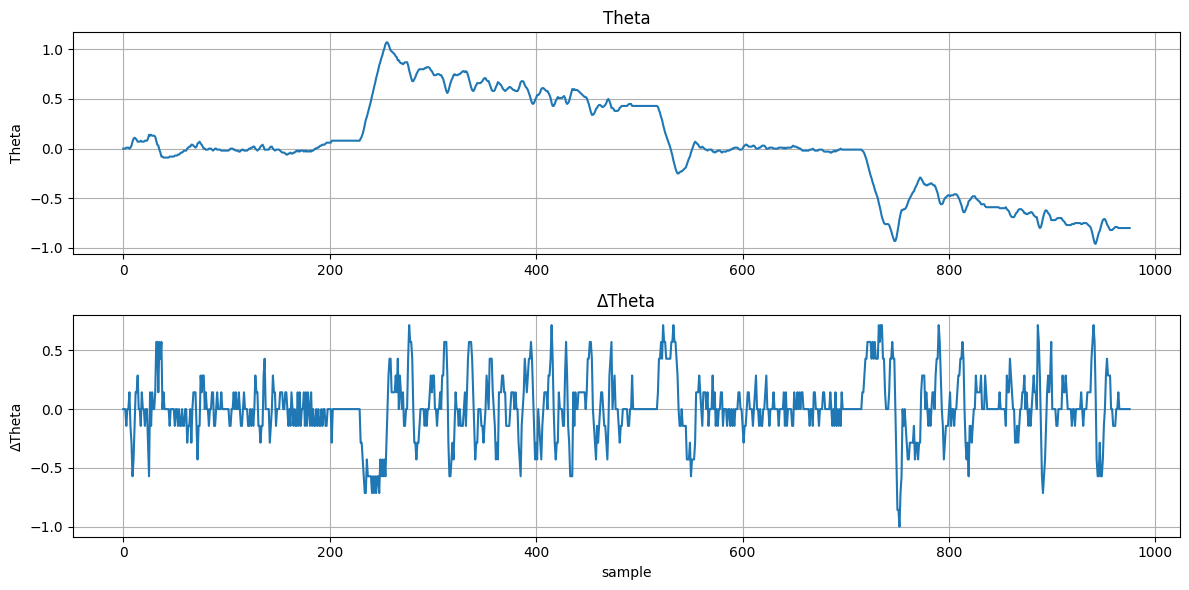

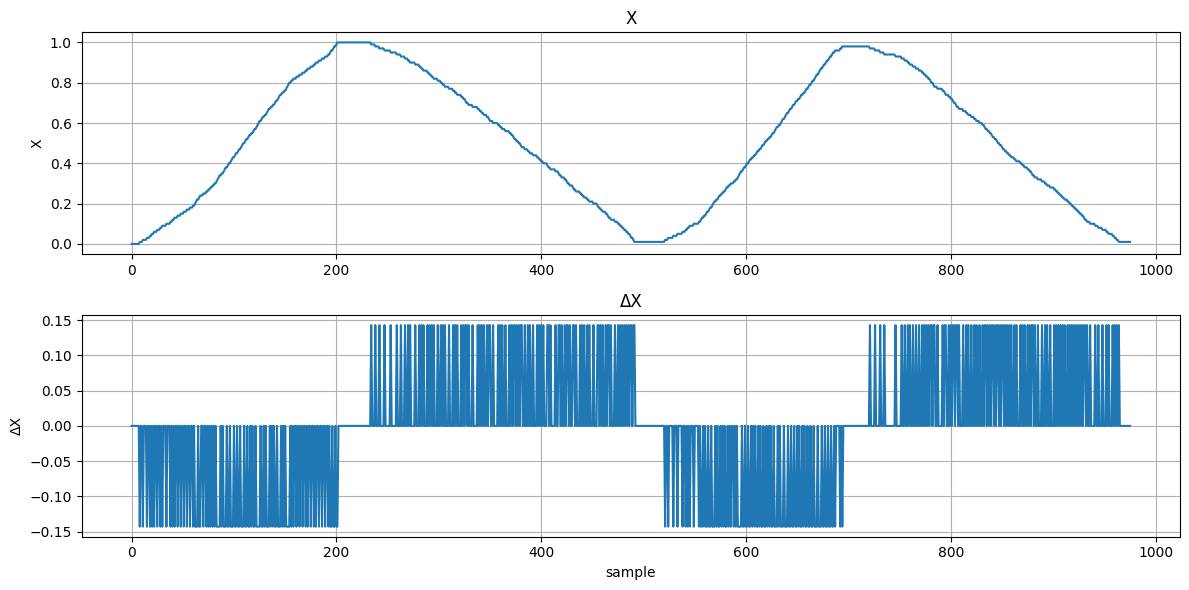

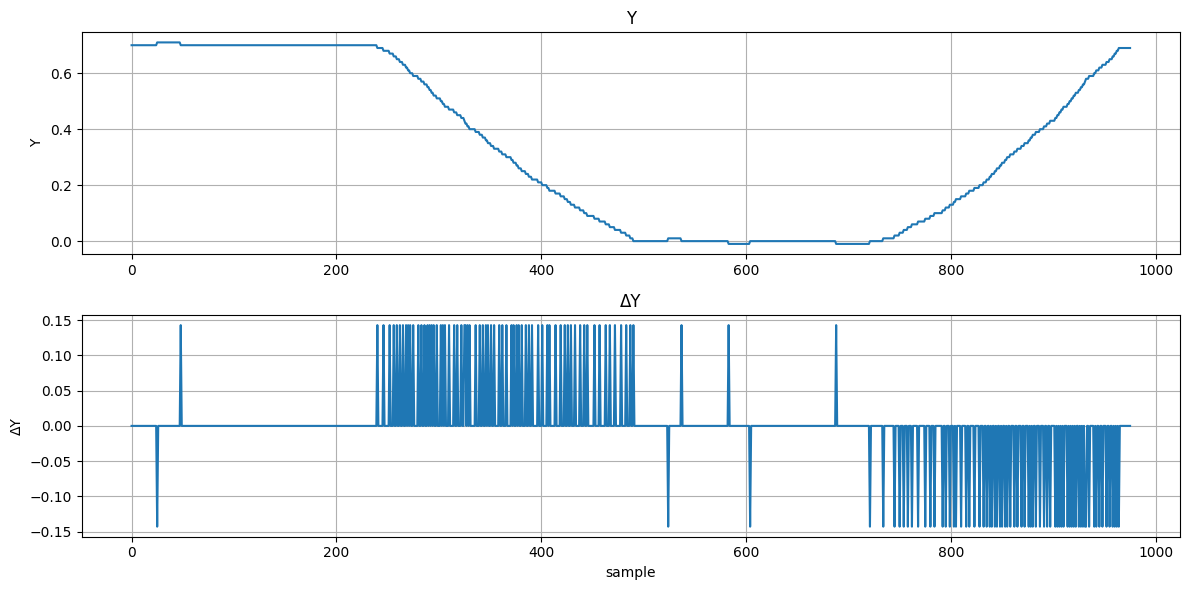

In [19]:
PlotTarget(Datasets[0], target="Theta")
PlotTarget(Datasets[0], target="X")
PlotTarget(Datasets[0], target="Y")